In [60]:
from keras import models
from keras.models import Model
from keras.layers import Input,Dense , Dropout #for layres(input, output, hidden)
from keras.utils import to_categorical# conversion into one-hot Encoding
from keras.datasets import mnist #contains img
from tensorflow.keras.utils import model_to_dot #to visualize into graph
from IPython.display import SVG #Display SVG img into jupyter notebook


In [61]:
import numpy as np

In [63]:
import livelossplot
plot_losses = livelossplot.PlotLossesKeras()

%matplotlib inline

num_rows = 28
num_cols = 28
num_classes = 10
Batch_size = 128 
EPOCHs = 10


In [64]:
def data_summary(X_train,y_train, X_test,y_test):
    print("X_train images shape=",X_train.shape)
    print("y_train lables shape=",y_train.shape)
    print("X_test imagesshape=",X_test.shape)
    print("y_test lables shape=",y_test.shape)
    print("Train lables=",y_test)
    print("test lables=",y_test)

In [65]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()  #loading data from the mnist dataset
data_summary(X_train,y_train, X_test,y_test) #Storing that data into the previously created function

X_train images shape= (60000, 28, 28)
y_train lables shape= (60000,)
X_test imagesshape= (10000, 28, 28)
y_test lables shape= (10000,)
Train lables= [7 2 1 ... 4 5 6]
test lables= [7 2 1 ... 4 5 6]


In [66]:
#reshaping the data (because ANN only accept the 2D data and MNIST contains 3D)
X_train = X_train.reshape(X_train.shape[0],num_rows*num_cols)
X_train = X_train.astype('float32')/255
X_test = X_test.reshape(X_test.shape[0],num_rows*num_cols)
X_test = X_test.astype('float32')/255

In [67]:
#One_Hot Encoding
y_train = to_categorical(y_train,num_classes)
y_test = to_categorical(y_test,num_classes)

In [68]:
data_summary(X_train,y_train, X_test,y_test)

X_train images shape= (60000, 784)
y_train lables shape= (60000, 10)
X_test imagesshape= (10000, 784)
y_test lables shape= (10000, 10)
Train lables= [[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
test lables= [[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [73]:
model = models.Sequential()
model.add(Dense(512,activation = "relu", input_shape=(num_rows*num_cols,)))
model.add(Dropout(0.5))
model.add(Dense(256,activation = "relu"))
model.add(Dropout(0.25))
model.add(Dense(10,activation='softmax'))

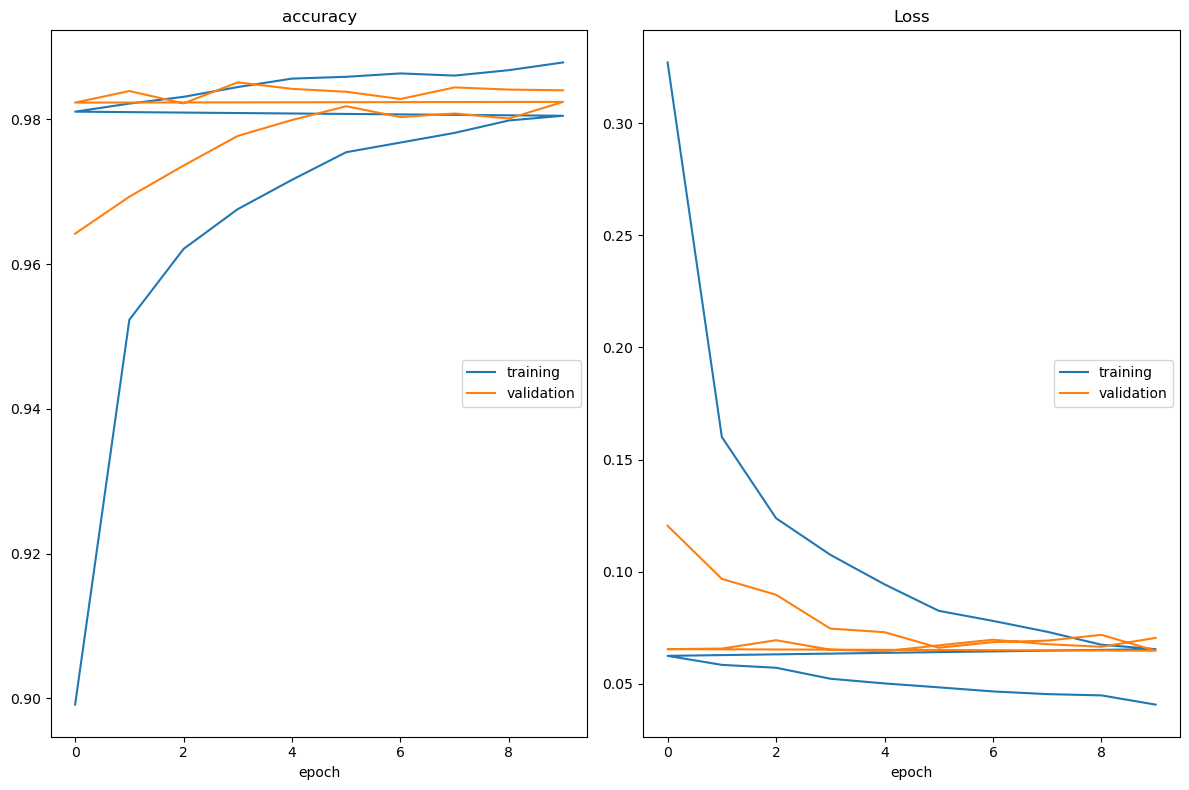

accuracy
	training         	 (min:    0.899, max:    0.988, cur:    0.988)
	validation       	 (min:    0.964, max:    0.985, cur:    0.984)
Loss
	training         	 (min:    0.041, max:    0.327, cur:    0.041)
	validation       	 (min:    0.064, max:    0.120, cur:    0.070)
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9879 - loss: 0.0407 - val_accuracy: 0.9840 - val_loss: 0.0704
total loss 0.07042116671800613
test Acuracy 0.984000027179718


In [82]:
#compile model
model.compile(optimizer='rmsprop',
             loss = 'categorical_crossentropy',
              metrics = ['accuracy']
             )

#train model
model.fit(X_train,y_train,
         batch_size =Batch_size,
         epochs =EPOCHs,
         callbacks = [plot_losses],
         verbose = 1,
         validation_data = (X_test,y_test))
score  = model.evaluate(X_test,y_test, verbose = 0)
print("total loss",score[0])
print("test Acuracy",score[1])

In [84]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,638 (4.09 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 535,820 (2.04 MB)

In [90]:
pip install pydot

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [93]:
import pydot
print(pydot.__version__)

4.0.1
